# `eda_training_charts.py`

EDA dữ liệu training (`sales.csv`) — 6 biểu đồ quan sát trước khi build model (toàn chuỗi, theo tháng, heatmap năm×tháng, mùa vụ, thứ trong tuần, hiệu ứng Tết) + số liệu đọc kèm. Notebook chạy đúng code gốc của `eda_training_charts.py`, chỉ khác: chart hiện INLINE ngay dưới cell, không sửa logic/số liệu.

In [1]:
%matplotlib inline
import os
os.chdir(r"/Users/lhoanghai_/Documents/Study/Dự án datathon2026")
__file__ = r"/Users/lhoanghai_/Documents/Study/Dự án datathon2026/EDA_Insight/phase1_descriptive/eda_training_charts.py"  # notebook không có __file__ mặc định -> gán thủ công để mọi Path(__file__)... trong code gốc resolve đúng thư mục như khi chạy .py


## Thiết lập / import

In [2]:
# EDA dữ liệu training (sales.csv) — 6 biểu đồ quan sát trước khi build model
# Output: EDA_Insight/output/phase1/*.png
# Chạy: python EDA_Insight/phase1_descriptive/eda_training_charts.py (sau khi activate .venv)

import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use("Agg")  # bỏ trong notebook để %matplotlib inline hiển thị chart
import matplotlib.pyplot as plt
from lunardate import LunarDate
from pathlib import Path

HERE = Path(__file__).resolve().parent           # EDA_Insight/phase1_descriptive/
OUT = HERE.parent / "output" / "phase1"          # EDA_Insight/output/phase1/
OUT.mkdir(parents=True, exist_ok=True)

C_REV = "#A32D2D"   # đỏ — Revenue, cố định mọi chart
C_COGS = "#185FA5"  # xanh — COGS
C_GRAY = "#888780"  # xám — nền/ngữ cảnh
C_ACCENT = "#534AB7"

plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "grid.linestyle": ":"})

sales = pd.read_csv(HERE.parent.parent / "data" / "sales.csv", parse_dates=["Date"])
sales["margin_pct"] = (sales["Revenue"] - sales["COGS"]) / sales["Revenue"] * 100

## 1. TOÀN CHUỖI: daily + MA30 + mốc break 2019

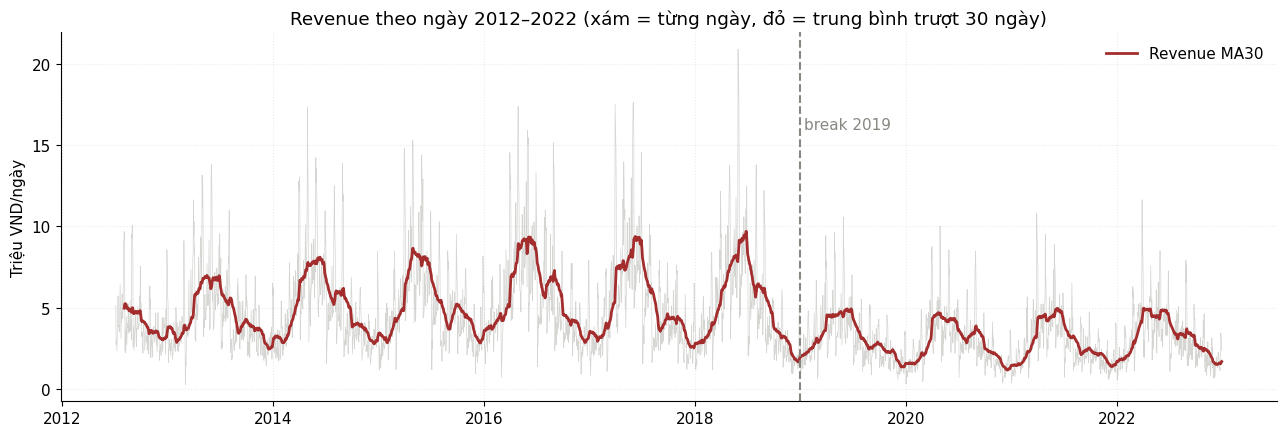

In [3]:
sales["MA30"] = sales["Revenue"].rolling(30).mean()
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(sales["Date"], sales["Revenue"] / 1e6, color=C_GRAY, alpha=0.35, lw=0.5)
ax.plot(sales["Date"], sales["MA30"] / 1e6, color=C_REV, lw=2, label="Revenue MA30")
ax.axvline(pd.Timestamp("2019-01-01"), color=C_GRAY, ls="--", lw=1.5)
ax.annotate("break 2019", xy=(pd.Timestamp("2019-01-15"), 16), color=C_GRAY)
ax.set_ylabel("Triệu VND/ngày")
ax.set_title("Revenue theo ngày 2012–2022 (xám = từng ngày, đỏ = trung bình trượt 30 ngày)")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(OUT / "01_daily_ma30.png", dpi=110); plt.show(); plt.close(fig)

**Phân tích chart 01 — Revenue theo ngày 2012-2022 (MA30)**

1. **Thể hiện gì:** trục X là ngày (2012-2022), trục Y là Revenue (triệu VND/ngày). Đường xám mảnh = Revenue từng ngày (nhiễu cao), đường đỏ đậm = trung bình trượt 30 ngày (MA30, lọc nhiễu để thấy xu hướng). Đường đứt nét đánh dấu mốc 2019-01-01.
2. **Insight:** MA30 cho thấy chu kỳ tăng-giảm mùa vụ lặp lại mỗi năm, và một cú sụt rõ rệt ngay tại mốc 2019 — khớp CAGR toàn kỳ 2013-2022 = **-3.80%/năm** nhưng KHÔNG đều: +6.79%/năm (2013-2015) → -6.24%/năm (2016-2018) → -4.21%/năm (2019-2021, riêng gross_profit rơi **-12.00%/năm**). Doanh thu theo năm (tỷ VND): đỉnh 2016 (2.10), đáy 2021 (1.04), 2022 hồi phục **+12.15% YoY**.
3. **Lưu ý:** đường xám (raw daily) dao động rất mạnh — không dùng để đọc xu hướng, chỉ MA30 (đỏ) phản ánh đúng hướng đi. CAGR theo giai đoạn tính trên 2 điểm đầu-cuối, nhạy với năm chọn, không phải hồi quy đầy đủ — không dùng để ngoại suy chính xác.


## 2. THÁNG: revenue + margin% (2 panel, KHÔNG dual-axis)

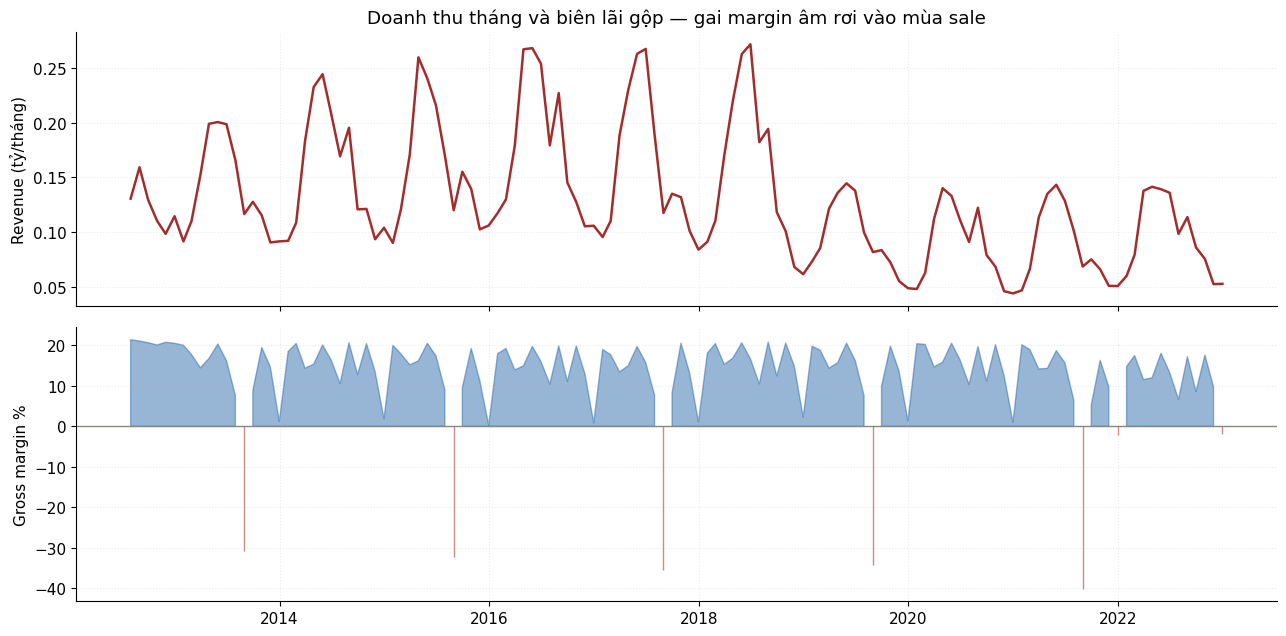

In [4]:
monthly = sales.set_index("Date").resample("ME")[["Revenue", "COGS"]].sum()
monthly["margin_pct"] = (monthly["Revenue"] - monthly["COGS"]) / monthly["Revenue"] * 100
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
ax1.plot(monthly.index, monthly["Revenue"] / 1e9, color=C_REV, lw=1.8)
ax1.set_ylabel("Revenue (tỷ/tháng)")
ax1.set_title("Doanh thu tháng và biên lãi gộp — gai margin âm rơi vào mùa sale")
ax2.fill_between(monthly.index, monthly["margin_pct"], 0,
                 where=monthly["margin_pct"] >= 0, color=C_COGS, alpha=0.45)
ax2.fill_between(monthly.index, monthly["margin_pct"], 0,
                 where=monthly["margin_pct"] < 0, color=C_REV, alpha=0.55)
ax2.axhline(0, color=C_GRAY, lw=1)
ax2.set_ylabel("Gross margin %")
fig.tight_layout(); fig.savefig(OUT / "02_monthly_margin.png", dpi=110); plt.show(); plt.close(fig)

**Phân tích chart 02 — Doanh thu tháng + Gross margin %**

1. **Thể hiện gì:** 2 panel share trục X (theo tháng, resample tháng 2012-2022). Panel trên = Revenue tổng theo tháng (tỷ VND). Panel dưới = Gross margin % (COGS/Revenue), tô xanh khi margin dương, tô đỏ khi margin **ÂM** (dưới đường 0).
2. **Insight:** các "gai" margin âm (đỏ) lặp lại có tính mùa vụ — khớp phát hiện định lượng ở Giai đoạn 2 (`diagnostic_summary.md`): toàn kỳ có **382 ngày lỗ gộp**, tập trung T7-9 (Urban Blowout, Fall Launch) và T11-12 (Year-End Sale) — do **47.9%** dòng hàng CÓ promo bán dưới giá vốn (so với chỉ 0.18% dòng không-promo, chênh 266 lần). Panel trên cũng cho thấy biên độ Revenue tháng co hẹp dần sau 2019, khớp break đã biết.
3. **Lưu ý:** chart này chỉ mô tả (Descriptive) — nguyên nhân "vì sao" margin âm (promo, category nào) đã được điều tra sâu ở Giai đoạn 2 (không lặp lại phân tích nhân quả ở đây); không tự suy diễn nguyên nhân chỉ từ chart này.


## 3. HEATMAP năm × tháng (sequential 1 hue)

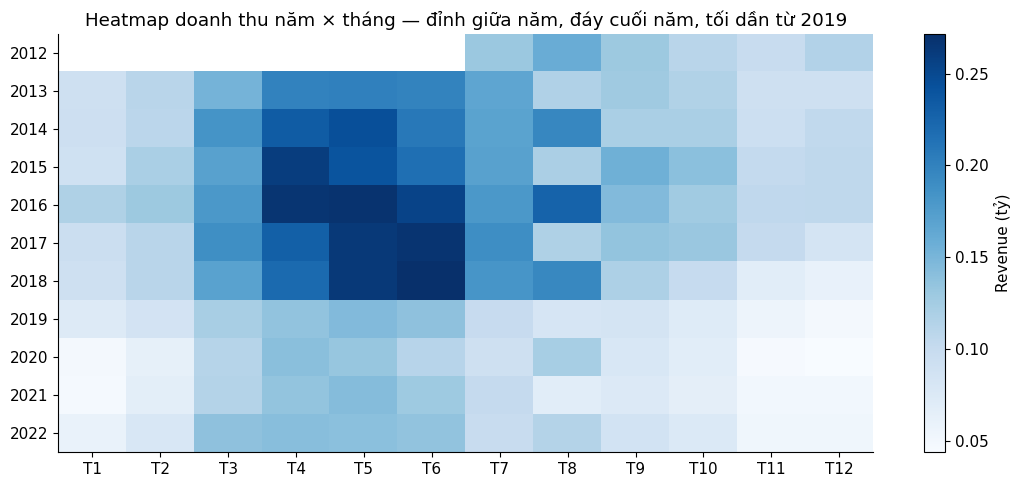

In [5]:
hm = sales.pivot_table(index=sales["Date"].dt.year, columns=sales["Date"].dt.month,
                       values="Revenue", aggfunc="sum") / 1e9
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(hm.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(12), [f"T{m}" for m in range(1, 13)])
ax.set_yticks(range(len(hm.index)), hm.index)
ax.grid(False)
fig.colorbar(im, label="Revenue (tỷ)")
ax.set_title("Heatmap doanh thu năm × tháng — đỉnh giữa năm, đáy cuối năm, tối dần từ 2019")
fig.tight_layout(); fig.savefig(OUT / "03_heatmap_year_month.png", dpi=110); plt.show(); plt.close(fig)

**Phân tích chart 03 — Heatmap doanh thu năm × tháng**

1. **Thể hiện gì:** heatmap, trục Y = năm (2012-2022), trục X = tháng (T1-T12), màu càng đậm (xanh dương đậm) = Revenue tổng tháng đó càng cao (tỷ VND).
2. **Insight:** hàng đậm nhất rơi vào 2016-2018 (đỉnh chu kỳ trước break), sáng dần rõ rệt từ 2019 — khớp CAGR âm giai đoạn 2019-2021. Trong mỗi hàng (mỗi năm), cột giữa năm (T4-6) luôn đậm hơn cột cuối năm (T11-12) — hình dạng mùa vụ trong năm giữ nguyên qua break, chỉ "biên độ" (độ đậm tổng thể) bị nén lại.
3. **Lưu ý:** hàng 2012 chỉ có nửa năm dữ liệu (thiếu T1-6) nên các ô T1-6/2012 trống/không đại diện — không so sánh trực tiếp hàng 2012 với các năm khác. Thang màu là tuyệt đối (tỷ VND) không phải %, dễ nhầm "năm nào tối hơn" là do ít ngày dữ liệu hơn — thực tế mọi năm trừ 2012 đều đủ 12 tháng.


## 4. MÙA VỤ CÓ BỀN VỮNG? — tỷ trọng từng tháng trong năm, 10 năm chồng lên nhau

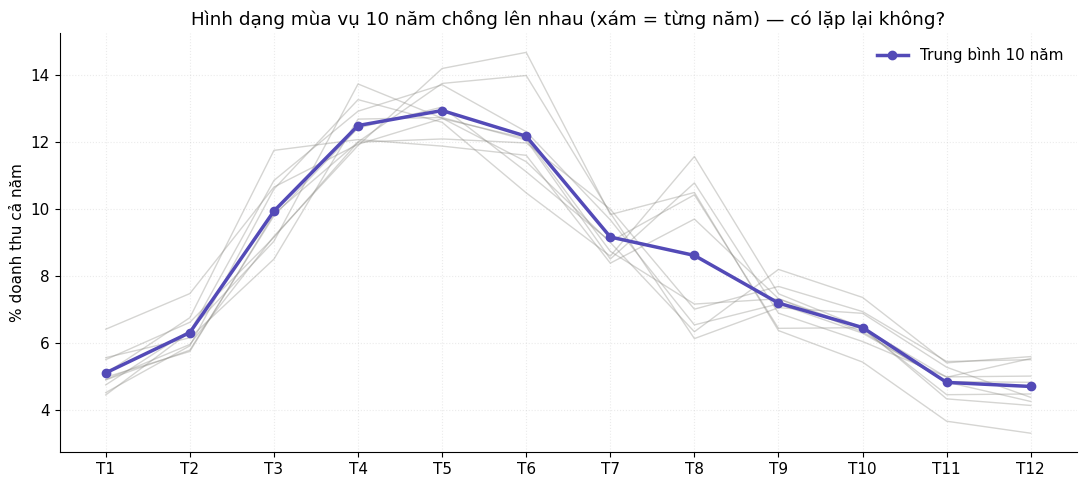

In [6]:
yr = sales[sales["Date"].dt.year.between(2013, 2022)].copy()
yr["year"], yr["month"] = yr["Date"].dt.year, yr["Date"].dt.month
share = (yr.groupby(["year", "month"])["Revenue"].sum()
         / yr.groupby("year")["Revenue"].sum()).unstack() * 100
fig, ax = plt.subplots(figsize=(11, 5))
for y in share.index:
    ax.plot(share.columns, share.loc[y], color=C_GRAY, alpha=0.35, lw=1)
ax.plot(share.columns, share.mean(), color=C_ACCENT, lw=2.5, marker="o",
        label="Trung bình 10 năm")
ax.set_xticks(range(1, 13), [f"T{m}" for m in range(1, 13)])
ax.set_ylabel("% doanh thu cả năm")
ax.set_title("Hình dạng mùa vụ 10 năm chồng lên nhau (xám = từng năm) — có lặp lại không?")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(OUT / "04_seasonal_shape.png", dpi=110); plt.show(); plt.close(fig)

**Phân tích chart 04 — Hình dạng mùa vụ 10 năm chồng lên nhau**

1. **Thể hiện gì:** trục X = tháng (T1-12), trục Y = % doanh thu tháng đó trên tổng doanh thu CẢ NĂM. Mỗi đường xám mảnh = 1 năm riêng (2013-2022), đường cam đậm = trung bình 10 năm.
2. **Insight:** 10 đường xám gần như trùng khít quanh đường trung bình — xác nhận hình dạng mùa vụ theo tháng RẤT ổn định qua 10 năm: đỉnh T4-6 (~12.5-13%/tháng, cao nhất T5 12.95%), đáy T11-12 (~4.7-4.8%/tháng, thấp nhất T12 4.71%) — đỉnh cao gấp ~2.7 lần đáy.
3. **Lưu ý:** tháng 8 có độ lệch chuẩn CAO NHẤT giữa các năm (±2.15 điểm %, các tháng khác chỉ ±0.5-1.3 điểm %) — 1-2 đường xám ở T8 tách khá xa đường trung bình (nhiều khả năng do "Mid-Year Sale" chạy năm có năm không). Không coi mùa vụ T8 là cố định tuyệt đối khi forecast, khác các tháng còn lại.


## 5. THỨ TRONG TUẦN

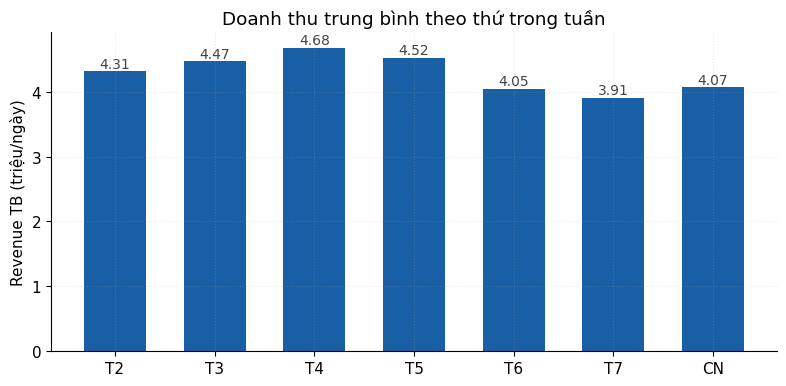

In [7]:
dow = sales.groupby(sales["Date"].dt.dayofweek)["Revenue"].mean() / 1e6
labels = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, dow.values, color=C_COGS, width=0.62)
for i, v in enumerate(dow.values):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=10, color="#444441")
ax.set_ylabel("Revenue TB (triệu/ngày)")
ax.set_title("Doanh thu trung bình theo thứ trong tuần")
fig.tight_layout(); fig.savefig(OUT / "05_day_of_week.png", dpi=110); plt.show(); plt.close(fig)

**Phân tích chart 05 — Doanh thu trung bình theo thứ trong tuần**

1. **Thể hiện gì:** biểu đồ cột, trục X = 7 thứ trong tuần (T2→CN), trục Y = Revenue trung bình (triệu VND/ngày), số ghi trên đầu mỗi cột.
2. **Insight:** đỉnh rơi vào thứ Tư, đáy vào thứ Bảy — chênh lệch ngày cao nhất/thấp nhất là **19.8%**. Khách tập trung đặt hàng giữa tuần, không phải cuối tuần — khác hành vi retail truyền thống (thường cuối tuần đông hơn), phù hợp đặc thù mua sắm online.
3. **Lưu ý:** đây là trung bình gộp TOÀN BỘ 3,833 ngày (2012-2022) — không tách theo giai đoạn trước/sau break 2019, nên không kết luận được pattern thứ-trong-tuần có đổi khác sau 2019 hay không chỉ từ chart này; biên độ chênh lệch (19.8%) nhỏ hơn nhiều biên độ mùa vụ theo tháng (gấp 2.7 lần) — day-of-week là tín hiệu phụ, không phải trục chính.


## 6. HIỆU ỨNG TẾT ±30 NGÀY

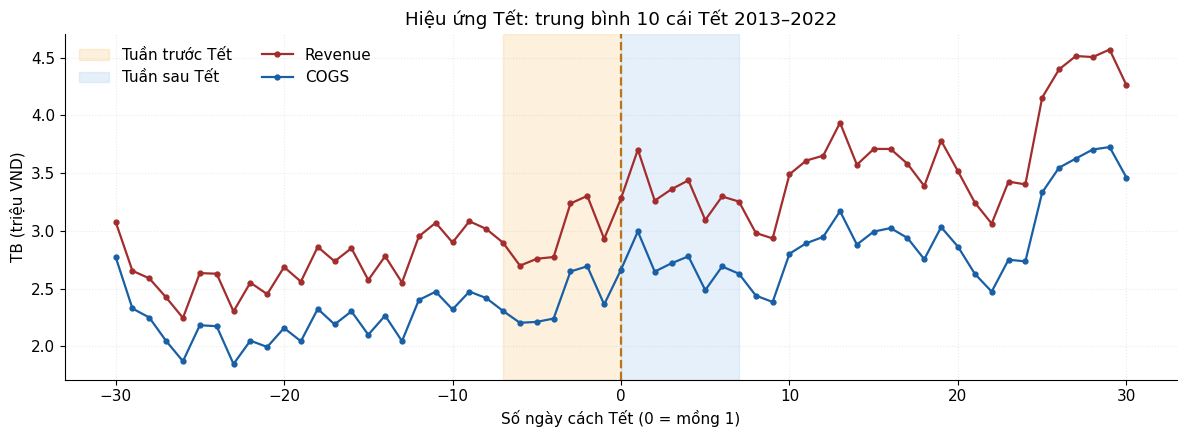

In [8]:
tet_dates = [pd.Timestamp(LunarDate(y, 1, 1).to_solar_date()) for y in range(2013, 2023)]
frames = []
for t in tet_dates:
    w = sales[(sales["Date"] >= t - pd.Timedelta(days=30)) &
              (sales["Date"] <= t + pd.Timedelta(days=30))].copy()
    w["offset"] = (w["Date"] - t).dt.days
    frames.append(w)
avg = pd.concat(frames).groupby("offset")[["Revenue", "COGS"]].mean() / 1e6
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.axvspan(-7, 0, color="#FAC775", alpha=0.25, label="Tuần trước Tết")
ax.axvspan(0, 7, color="#B5D4F4", alpha=0.35, label="Tuần sau Tết")
ax.axvline(0, color="#BA7517", ls="--", lw=1.6)
ax.plot(avg.index, avg["Revenue"], "o-", color=C_REV, ms=3.5, lw=1.6, label="Revenue")
ax.plot(avg.index, avg["COGS"], "o-", color=C_COGS, ms=3.5, lw=1.6, label="COGS")
ax.set_xlabel("Số ngày cách Tết (0 = mồng 1)")
ax.set_ylabel("TB (triệu VND)")
ax.set_title("Hiệu ứng Tết: trung bình 10 cái Tết 2013–2022")
ax.legend(frameon=False, ncol=2)
fig.tight_layout(); fig.savefig(OUT / "06_tet_effect.png", dpi=110); plt.show(); plt.close(fig)

**Phân tích chart 06 — Hiệu ứng Tết (trung bình 10 cái Tết 2013-2022)**

1. **Thể hiện gì:** trục X = số ngày cách Tết (âm = trước, 0 = mồng 1, dương = sau), trục Y = Revenue/COGS trung bình (triệu VND), gộp trung bình 10 cái Tết 2013-2022. Vùng tô cam = tuần trước Tết, vùng tô xanh = tuần sau Tết.
2. **Insight:** Revenue thấp nhất ở vùng -30..-15 ngày (2.60 triệu/ngày — đáy sâu nhất), tăng dần qua tuần sau Tết (3.34 triệu) tới vùng hồi phục +15..+30 ngày (3.83 triệu, cao hơn đáy **~+47%**). Cả năm trung bình là 4.29 triệu/ngày — nghĩa là toàn bộ cửa sổ ±30 ngày quanh Tết đều THẤP hơn mức trung bình năm, vì đây vốn là mùa thấp điểm (T1-2 chỉ chiếm 5.11%/6.32% doanh thu năm).
3. **Lưu ý:** đây là số liệu GỘP trung bình 10 năm — biên độ dao động thực tế khác nhau rất nhiều giữa các năm (tuần trước Tết dao động từ -3.6% năm 2019 đến -47.4% năm 2020 so baseline riêng năm đó) — giả thuyết "Tết luôn tạo pattern giống nhau mỗi năm" đã bị **BÁC BỎ** khi tách theo từng năm; không dùng đường trung bình này như 1 hệ số Tết cố định cho model.


## SỐ LIỆU KÈM PHÂN TÍCH

In [9]:
print("=== Số liệu đọc kèm chart ===")
print(f"Corr(Revenue, COGS) theo ngày: {sales['Revenue'].corr(sales['COGS']):.4f}")
print(f"Tỷ lệ COGS/Revenue: TB {(sales['COGS']/sales['Revenue']).mean():.3f}, "
      f"độ lệch chuẩn {(sales['COGS']/sales['Revenue']).std():.3f}")
print(f"\nDoW (triệu): {dict(zip(labels, dow.round(2)))}")
print(f"Chênh cao nhất vs thấp nhất trong tuần: "
      f"{(dow.max()/dow.min()-1)*100:.1f}%")
print("\nTỷ trọng tháng (TB % ± std qua 10 năm):")
for m in range(1, 13):
    print(f"  T{m:<2}: {share[m].mean():5.2f}% ± {share[m].std():.2f}")
top5 = sales.nlargest(5, "Revenue")[["Date", "Revenue"]]
print("\nTop 5 ngày doanh thu cao nhất:")
for _, r in top5.iterrows():
    print(f"  {r['Date'].date()}  {r['Revenue']/1e6:6.1f} triệu")
print(f"\nĐã lưu 6 chart vào {OUT}")

=== Số liệu đọc kèm chart ===
Corr(Revenue, COGS) theo ngày: 0.9760
Tỷ lệ COGS/Revenue: TB 0.875, độ lệch chuẩn 0.127

DoW (triệu): {'T2': 4.31, 'T3': 4.47, 'T4': 4.68, 'T5': 4.52, 'T6': 4.05, 'T7': 3.91, 'CN': 4.07}
Chênh cao nhất vs thấp nhất trong tuần: 19.8%

Tỷ trọng tháng (TB % ± std qua 10 năm):
  T1 :  5.11% ± 0.58
  T2 :  6.32% ± 0.53
  T3 :  9.95% ± 1.01
  T4 : 12.50% ± 0.64
  T5 : 12.95% ± 0.74
  T6 : 12.18% ± 1.27
  T7 :  9.17% ± 0.62
  T8 :  8.62% ± 2.15
  T9 :  7.20% ± 0.55
  T10:  6.47% ± 0.53
  T11:  4.83% ± 0.55
  T12:  4.71% ± 0.74

Top 5 ngày doanh thu cao nhất:
  2018-05-30    20.9 triệu
  2018-05-31    19.3 triệu
  2018-06-01    19.2 triệu
  2017-06-01    17.6 triệu
  2018-06-02    17.5 triệu

Đã lưu 6 chart vào /Users/lhoanghai_/Documents/Study/Dự án datathon2026/EDA_Insight/output/phase1
